<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Hierarchical Clustering with sklearn</b>
</h1>
<div style="font-family:'Times New Roman';">
Now lets actually run it. I'll use sklearn's AgglomerativeClustering on the mall customers data, the same income vs spending score thing i used for K-Means and DBSCAN. I also want to try the diffrent linkage methods and see how much the clusters change.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# just checking the ranges quickly
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


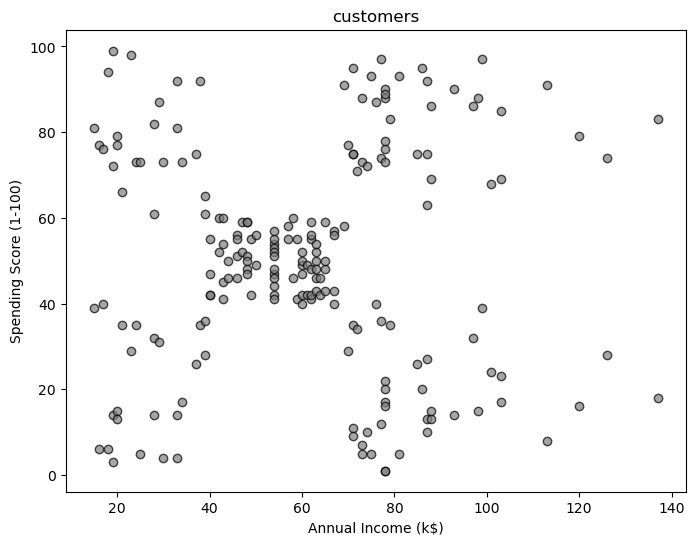

In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k', alpha=0.7)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("customers")
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Running Agglomerative Clustering</b>
</h2>
<div style="font-family:'Times New Roman';">
Lets start with 5 clusters and ward linkage. Ward usually works well when the clusters are roughly round blobs, which this data kind of is.
</div>

In [4]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = model.fit_predict(X)

print(labels[:20])

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]


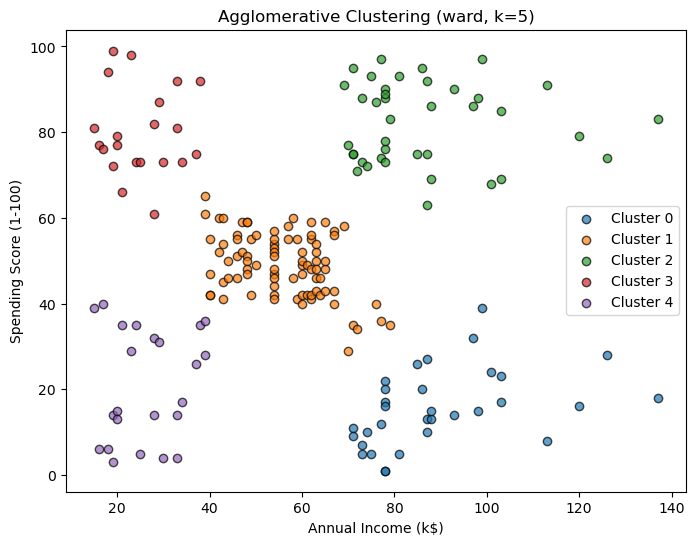

In [5]:
plt.figure(figsize=(8, 6))
for c in range(5):
    plt.scatter(X[labels == c, 0], X[labels == c, 1], label=f"Cluster {c}", edgecolors='k', alpha=0.7)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Agglomerative Clustering (ward, k=5)")
plt.legend()
plt.show()

## Trying the different linkage methods

i was curious how the four linkage methods compare on this same data, so let me just loop over them and plot all four next to each other.

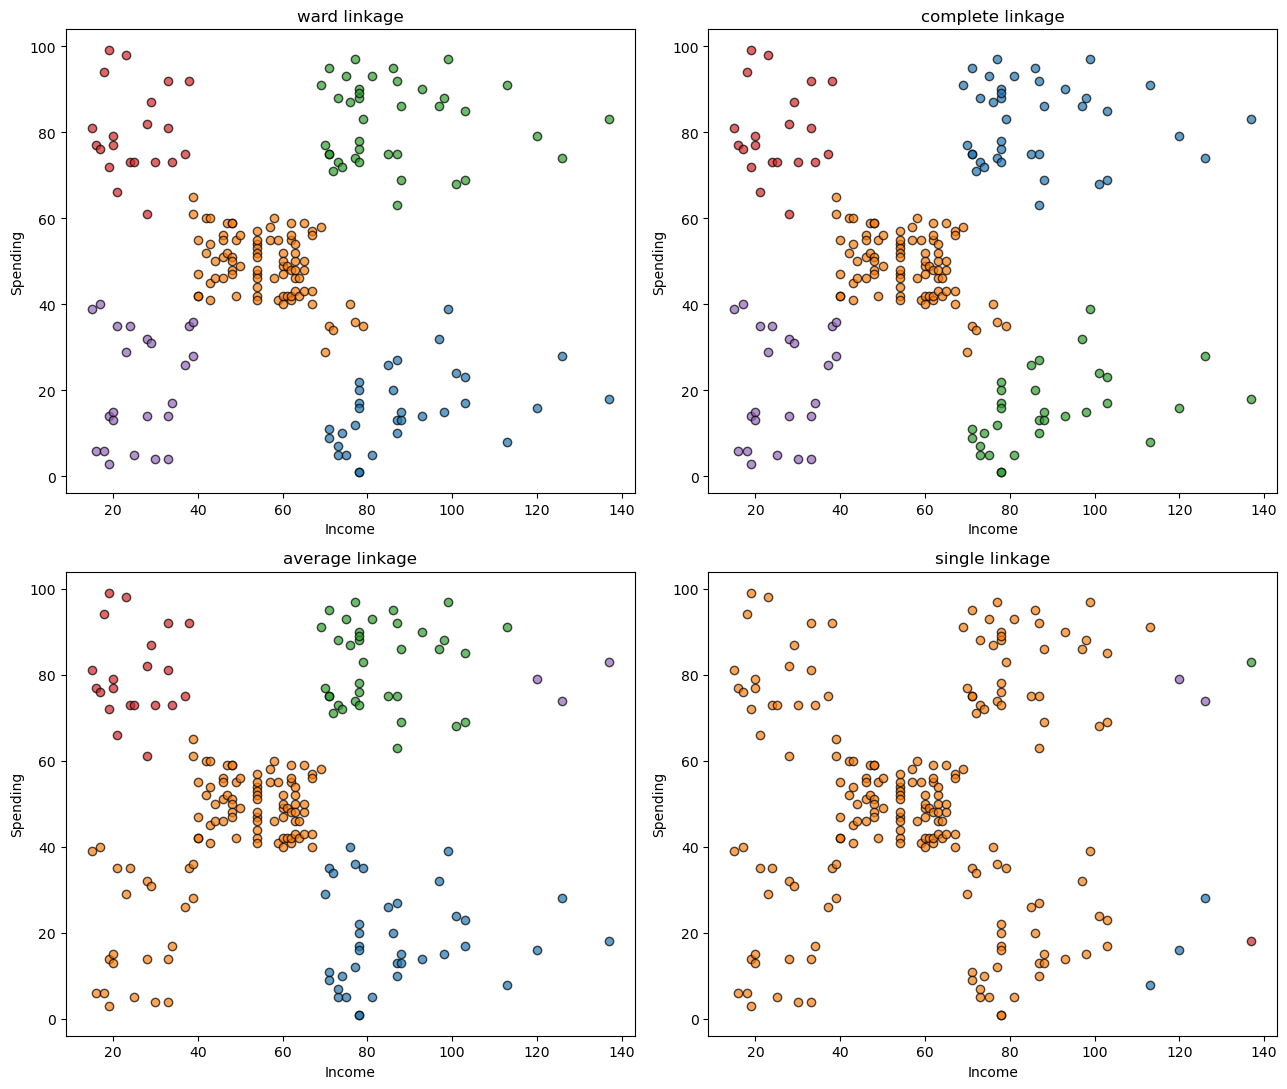

In [8]:
linkages = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, link in zip(axes.flat, linkages):
    lab = AgglomerativeClustering(n_clusters=5, linkage=link).fit_predict(X)
    for c in range(5):
        ax.scatter(X[lab == c, 0], X[lab == c, 1], edgecolors='k', alpha=0.7)
    ax.set_title(f"{link} linkage")
    ax.set_xlabel("Income")
    ax.set_ylabel("Spending")

# instead of fixing n_clusters i could also cut by a distance instead, like:
# AgglomerativeClustering(n_clusters=None, distance_threshold=150)
plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>So which linkage is best here?</b>
</h2>
<div style="font-family:'Times New Roman';">
From the plots, ward and complete give the nicest separated groups for this data. Single linkage looks bad, it kind of chains most of the points into one giant cluster and leaves a couple of tiny ones, which is a known thing single linkage does. Average is somewhere in between.
</div>

### quick takeaways

- agglomerative clustering in sklearn is basicaly one line, you just pick n_clusters and the linkage
- the linkage method really changes the result, ward was the best looking one here
- single linkage chained everything together, good to remember as what not to use on blobby data

next i'll build the dendrogram for this same data and use it to actually decide the number of clusters instead of just guessing 5.